🌊 Melatih Agen 'Tandon Shaka Hybrid'...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -960     |
| time/              |          |
|    fps             | 4943     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -884        |
| time/                   |             |
|    fps                  | 3507        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013098754 |
|    clip_fraction        | 0.0923      |
|    clip_range       

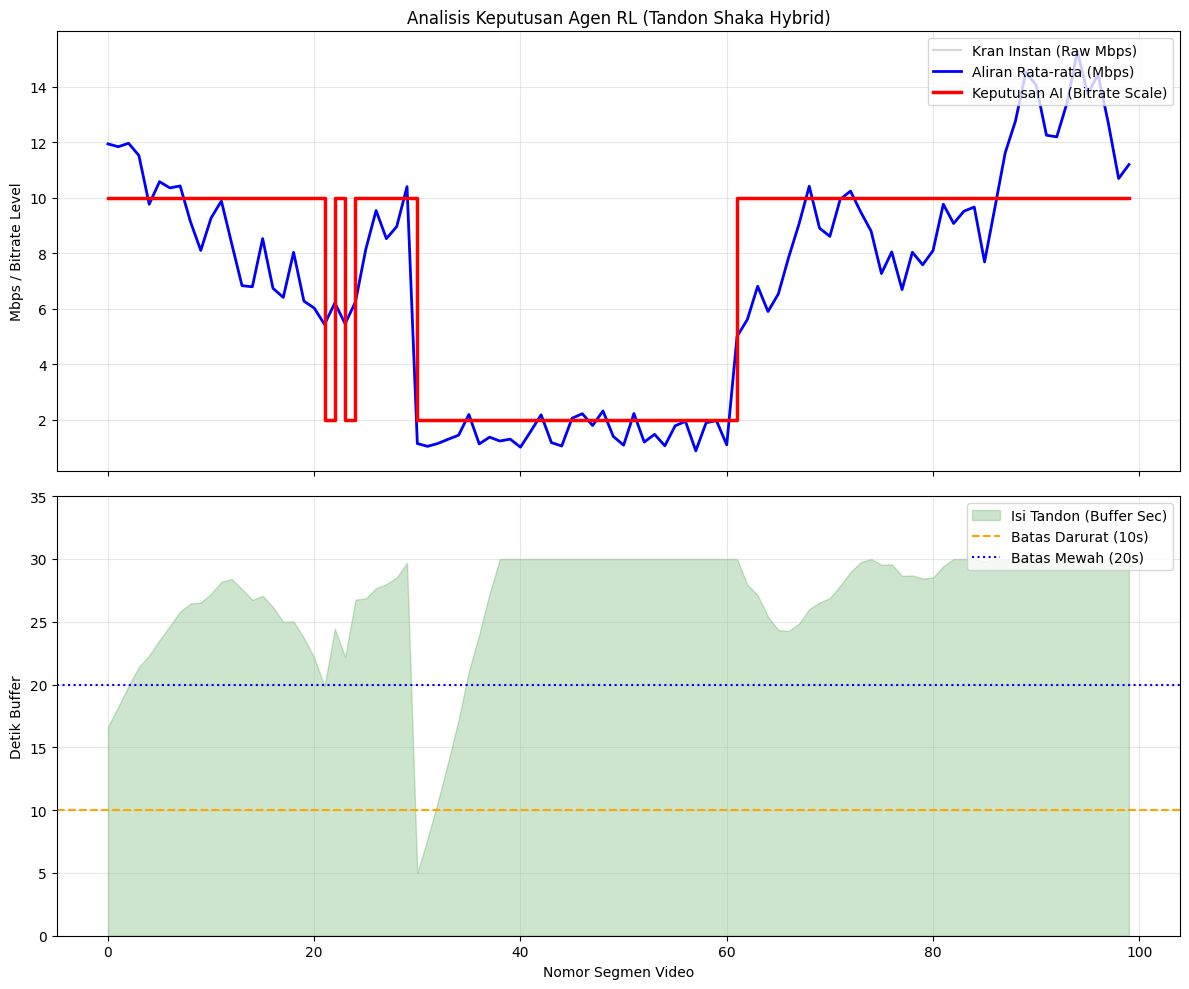

In [6]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import os
from collections import deque
import matplotlib.pyplot as plt
import pandas as pd

class TandonShakaEnv(gym.Env):
    """
    Gabungan Logika Tandon Air dengan Metrik Riil Shaka Player (Fase 1).
    State: [Buffer, Throughput, LastAction, RTT, DroppedFrames, Buffer_Trend, TP_Trend]
    """
    def __init__(self):
        super(TandonShakaEnv, self).__init__()
        
        self.bitrates = [0.5, 2.5, 8.0] # Mbps (Low, Mid, High)
        
        # Observation Space (7 Variabel)
        # [Buffer, Throughput, LastQual, RTT, Dropped, BufTrend, TPTrend]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 0, -5, -5]),
            high=np.array([30, 20, 2, 1000, 100, 5, 5]),
            dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)
        
        self.buffer_history = deque([15.0, 15.0], maxlen=2)
        self.tp_history = deque([12.0, 12.0], maxlen=2)
        self.state = None
        self.max_steps = 100
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.buffer_history = deque([15.0, 15.0], maxlen=2)
        self.tp_history = deque([12.0, 12.0], maxlen=2)
        # State: [Buffer, TP, Action, RTT, Dropped, BufTrend, TPTrend]
        self.state = np.array([15.0, 12.0, 1.0, 40.0, 0.0, 0.0, 0.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, last_tp, last_action, rtt, dropped, _, _ = self.state
        chosen_bitrate = self.bitrates[action]
        
        # 1. Simulasi Dinamika Jaringan
        if 30 <= self.current_step <= 60:
            raw_tp = np.random.uniform(0.8, 2.5) # Drop parah
        else:
            raw_tp = np.clip(last_tp + np.random.uniform(-2.0, 2.0), 5.0, 18.0)
        
        # 2. Dinamika Tandon
        seg_duration = 5.0
        download_time = (chosen_bitrate * seg_duration / (raw_tp + 0.1)) + (rtt/1000)
        stalling = max(0, download_time - buffer)
        
        new_buffer = max(0, buffer - download_time) + seg_duration
        new_buffer = min(new_buffer, 30.0)
        
        # Hitung Tren untuk State berikutnya
        buf_trend = new_buffer - buffer
        tp_trend = raw_tp - last_tp
        
        # 3. Reward (Logika Tandon Air)
        reward = chosen_bitrate * 1.0 # Reward dasar kualitas
        reward -= abs(action - last_action) * 0.5 # Penalty plin-plan (Switching)
        
        if stalling > 0:
            reward -= 60.0 # Penalty macet (Stalling)
        
        if new_buffer < 10.0 and action == 2:
            reward -= 20.0 # Aturan Safety: Buffer tipis dilarang pilih High
            
        if action == 0 and raw_tp > 10.0 and new_buffer > 20.0:
            reward -= 10.0 # Aturan Pelit: Internet kencang dilarang pilih Low
            
        # 4. Update State
        self.state = np.array([
            new_buffer, raw_tp, float(action), 
            40.0, 0.0, # RTT & Dropped (Simulasi konstan)
            buf_trend, tp_trend
        ], dtype=np.float32)
        
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self.state, reward, done, False, {"raw_tp": raw_tp}

def run_training_and_visualize():
    print("🌊 Melatih Agen 'Tandon Shaka Hybrid'...")
    env = TandonShakaEnv()
    
    # 1. PROSES TRAINING
    model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.0003, ent_coef=0.01)
    model.learn(total_timesteps=90000)
    
    # Simpan Model
    model.save("ndn_video_brain_tandon_final")
    print("✅ Model Berhasil Disimpan.")

    # 2. PROSES EVALUASI UNTUK GRAFIK
    print("\n📊 Memulai Evaluasi untuk Visualisasi...")
    obs, _ = env.reset()
    history = []
    
    for i in range(100):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        
        history.append({
            'Segmen': i,
            'Throughput_Raw': info['raw_tp'],
            'Throughput_Avg': obs[1],
            'Buffer_Level': obs[0],
            'Action_Quality': action
        })
        if done: break

    df = pd.DataFrame(history)

    # 3. GENERASI GRAFIK
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Grafik Jaringan vs Keputusan Bitrate
    ax1.plot(df['Segmen'], df['Throughput_Raw'], label='Kran Instan (Raw Mbps)', color='gray', alpha=0.3)
    ax1.plot(df['Segmen'], df['Throughput_Avg'], label='Aliran Rata-rata (Mbps)', color='blue', linewidth=2)
    # Skala Action 0,1,2 dipetakan ke 2, 5, 10 untuk visualisasi yang jelas di grafik
    ax1.step(df['Segmen'], df['Action_Quality'] * 4 + 2, label='Keputusan AI (Bitrate Scale)', color='red', linewidth=2.5)
    ax1.set_title("Analisis Keputusan Agen RL (Tandon Shaka Hybrid)")
    ax1.set_ylabel("Mbps / Bitrate Level")
    ax1.legend(loc='upper right')
    ax1.grid(alpha=0.3)
    
    # Grafik Isi Tandon (Buffer)
    ax2.fill_between(df['Segmen'], df['Buffer_Level'], color='green', alpha=0.2, label='Isi Tandon (Buffer Sec)')
    ax2.axhline(y=10, color='orange', linestyle='--', label='Batas Darurat (10s)')
    ax2.axhline(y=20, color='blue', linestyle=':', label='Batas Mewah (20s)')
    ax2.set_ylabel("Detik Buffer")
    ax2.set_xlabel("Nomor Segmen Video")
    ax2.set_ylim(0, 35)
    ax2.legend(loc='upper right')
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_training_and_visualize()